# 1. Configuration

In [1]:
import pandas as pd

usage = pd.read_csv(f"dataset/usage_monthly.csv")
tickets = pd.read_csv(f"dataset/support_tickets_monthly.csv")
renewals = pd.read_csv(f"dataset/renewals.csv")
companies = pd.read_csv(f"dataset/companies.csv")
contracts = pd.read_csv(f"dataset/contracts.csv")

# Aggregate usage
usage_agg = usage.groupby("contract_id").agg({
    "logins_total": "mean",
    "active_users": "mean",
    "feature_adoption_score": "mean"
}).reset_index()

# Aggregate tickets
tickets_agg = tickets.groupby("contract_id").agg({
    "ticket_count": "mean",
    "avg_resolution_hours": "mean",
    "csat_score": "mean"
}).reset_index()

# Merge everything
df = contracts.merge(usage_agg, on="contract_id") \
              .merge(tickets_agg, on="contract_id") \
              .merge(renewals, on="contract_id")

In [2]:
from sklearn.model_selection import train_test_split

features = [
    "logins_total_x",
    "active_users_x",
    "feature_adoption_score",
    "ticket_count",
    "avg_resolution_hours",
    "csat_score",
    "seat_change"
]

X = df[features].fillna(df[features].mean())
y = df["renewed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. ML Model (Logistic Regression)

In [3]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [4]:
from sklearn.metrics import accuracy_score

preds = model.predict(X_test)

accuracy_score(y_test, preds)

0.756

In [5]:
pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_[0]
}).sort_values(by="coefficient", ascending=False)

,feature,coefficient
3,ticket_count,0.173100
1,active_users_x,0.093809
2,feature_adoption_score,0.084703
6,seat_change,0.006941
0,logins_total_x,-0.000477
4,avg_resolution_hours,-0.016518
5,csat_score,-0.042292


# 3. Time-based Churn Signals

In [7]:
import numpy as np

def compute_trend(x):
    x = x.dropna(subset=["month_index", "logins_total"])
    
    if len(x) < 2:
        return 0
    
    try:
        return np.polyfit(x["month_index"], x["logins_total"], 1)[0]
    except:
        return 0

df_trend = (
    usage.groupby("contract_id")
    .apply(compute_trend)
    .reset_index()
    .rename(columns={0: "login_trend"})
)

first_last = usage.sort_values("month_index").groupby("contract_id").agg(
    first_logins=("logins_total","first"),
    last_logins=("logins_total","last")
)

first_last["change"] = first_last["last_logins"] - first_last["first_logins"]
first_last = first_last.reset_index()

In [8]:
print(df.shape)
print(df_trend.shape)
print(first_last.shape)

(5000, 26)
(5000, 2)
(5000, 4)


In [9]:
if "login_trend" in df.columns:
    df = df.drop(columns=["login_trend"])

if "change" in df.columns:
    df = df.drop(columns=["change"])

df = df.merge(df_trend, on="contract_id", how="left")

first_last = first_last.reset_index()

df = df.merge(
    first_last[["contract_id", "change"]],
    on="contract_id",
    how="left"
)

df["login_trend"] = df["login_trend"].fillna(0)
df["change"] = df["change"].fillna(0)

In [10]:
df[["login_trend", "change"]].describe()

,login_trend,change
count,5.000000e+03,5000.000000
mean,4.186582e-02,0.699200
std,2.723386e+01,110.455004
min,-9.835000e+02,-1967.000000
25%,-3.428571e+00,-24.000000
50%,-2.980690e-17,0.000000
75%,3.200000e+00,24.000000
max,5.380000e+02,2502.000000


<Axes: title={'center': 'login_trend'}, xlabel='renewed'>

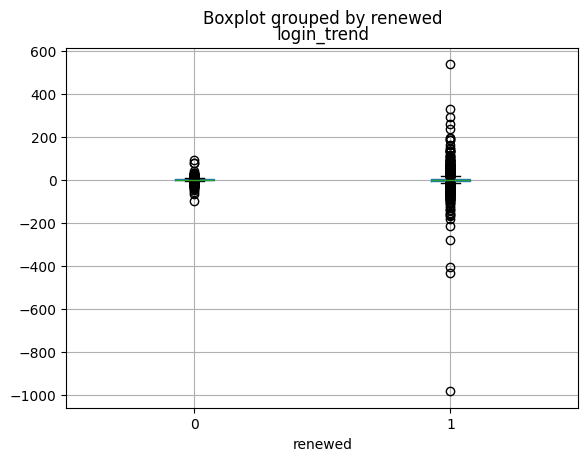

In [11]:
import matplotlib

df.boxplot(column="login_trend", by="renewed")

In [23]:
features = [
    "logins_total_x",
    "active_users_x",
    "feature_adoption_score",
    "ticket_count",
    "avg_resolution_hours",
    "csat_score",
    "seat_change",
    "login_trend",      # NEW
    "change"            # NEW
]

X = df[features].fillna(df[features].mean())
y = df["renewed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

print(len(features))
print(len(model.coef_[0]))

preds = model.predict(X_test)

accuracy_score(y_test, preds)

9
9


0.756

In [24]:
pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_[0]
}).sort_values(by="coefficient", ascending=False)

,feature,coefficient
3,ticket_count,0.176057
1,active_users_x,0.094418
2,feature_adoption_score,0.085505
6,seat_change,0.006700
7,login_trend,0.005590
8,change,-0.000132
0,logins_total_x,-0.000612
4,avg_resolution_hours,-0.016692
5,csat_score,-0.042837
